In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv('registros_tiempos_costos.csv')
df.head()
df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y')
df = df.sort_values(['proyecto_id', 'fecha']).reset_index(drop=True)
df.dtypes

registro_id              int64
proyecto_id              int64
proyecto                   str
departamento               str
empleado_id              int64
empleado                   str
rol                        str
fecha           datetime64[us]
tarea                      str
horas                  float64
tarifa_hora              int64
costo                  float64
presupuesto              int64
dtype: object

In [4]:
horas_por_rol = df.groupby('rol')['horas'].sum().sort_values(ascending=False)
horas_por_rol

rol
Frontend    738.9
Data/ML     708.8
Backend     679.5
QA          668.9
Name: horas, dtype: float64

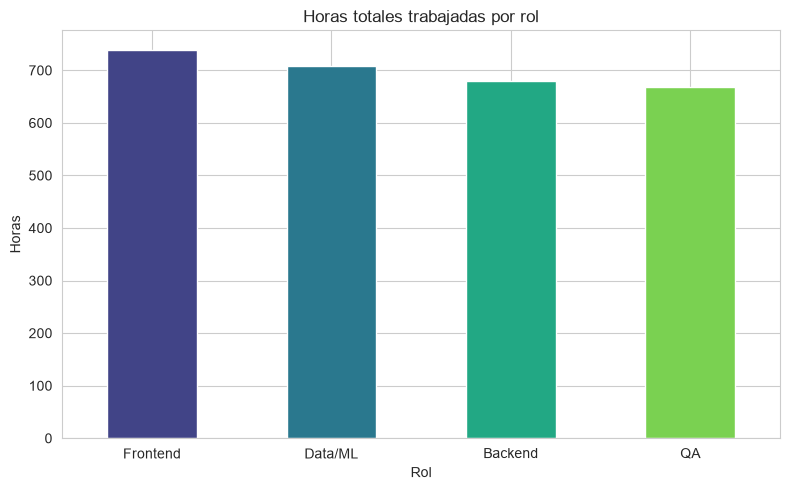

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
horas_por_rol.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(horas_por_rol)))
ax.set_title('Horas totales trabajadas por rol')
ax.set_xlabel('Rol')
ax.set_ylabel('Horas')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Las horas entre los 4 roles parecen estar bien distribuidas y son casi similares, con una dif. de <70 hrs desde Frontend (que acumula mas hotas) hasta QA (que acumula menos horas); sugiriendo que la carga de trabajo es pareja y que un sobrecosto en algún proyecto probablemente no viene de que un solo rol esté saturado.